# Module 11 Lab: Real-Time Object Tracking and Zone-Based Analytics

Welcome to an advanced topic in computer vision! In this lab, you will learn how to not just detect objects, but **track** them across video frames. You will also learn how to perform **zone-based analytics**, which involves analyzing object behavior within a specific region of the video.

**What you'll learn:**
- The difference between object detection and object tracking.
- How to use a pre-trained model to track objects in a video.
- How to define a 'zone' and count objects that enter it.

## Learning Objectives

By the end of this lab, you will be able to:

- **Differentiate** between object detection and object tracking.
- **Implement** an object tracking pipeline using the YOLO model.
- **Design** and implement a zone for analytics.
- **Analyze** the behavior of objects within a defined zone.

## 1. Setup and Installation

We will continue to use the `ultralytics` and `opencv-python` libraries.


In [1]:
%pip install ultralytics opencv-python requests

Now, let's import the necessary components.

In [2]:
from ultralytics import YOLO
import cv2
import requests
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

## 2. Understanding Object Tracking

### Object Detection vs. Object Tracking

- **Object Detection** is the process of identifying and locating objects in a single image or frame. It answers the question, 'What objects are in this frame and where are they?'
- **Object Tracking** is the process of identifying an object and following it across multiple frames. It answers the question, 'Where is this specific object going?' Tracking assigns a unique ID to each detected object, allowing it to be followed over time.

### Why is Tracking Useful?

Tracking is essential for many real-world applications, such as:
- **Retail Analytics:** Counting how many people enter a store and where they go.
- **Traffic Management:** Monitoring the flow of cars on a highway.
- **Security:** Following a person of interest through a building.

## Part 1: Coded Demonstration

In this part, we will track cars in a video and count how many of them enter a specific zone.

In [3]:
# 1. Load the YOLO model
model = YOLO('yolov8n.pt')

In [14]:
# 2. Download a video to analyze
# Using a reliable sample video for car detection
video_url = 'https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/car-detection.mp4'
video_path = 'highway.mp4'

r = requests.get(video_url, stream=True)
with open(video_path, 'wb') as f:
    for chunk in r.iter_content(chunk_size=1024*1024):
        if chunk:
            f.write(chunk)

print("Video downloaded successfully!")

Video downloaded successfully!


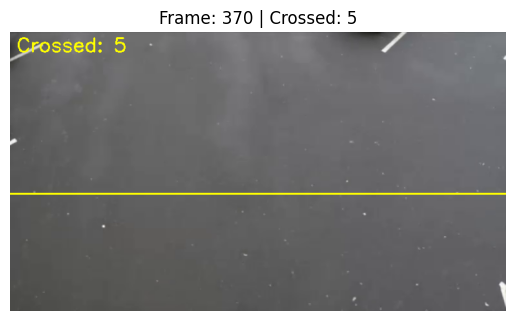

Finished processing 377 frames.


In [15]:
# 3. Create the Tracking and Zone Analytics Agent
from IPython.display import clear_output, display

def tracking_agent(video_path):
    print(f"Starting tracking agent for {video_path}...")
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Could not open video file.")
        return

    # Define the zone (a horizontal line in this case)
    zone_y = 250

    # Store the IDs of objects that have crossed the zone
    crossed_objects = set()
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # Track objects in the frame
        results = model.track(frame, persist=True, verbose=False)

        # Get the annotated frame with bounding boxes and track IDs
        annotated_frame = results[0].plot()

        # Draw the zone line
        cv2.line(annotated_frame, (0, zone_y), (frame.shape[1], zone_y), (0, 255, 255), 2)

        # Check if any objects have crossed the zone
        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()

            for box, track_id in zip(boxes, track_ids):
                # Check if the bottom of the box has crossed the line
                if box[3] > zone_y and track_id not in crossed_objects:
                    crossed_objects.add(track_id)

        # Display the total count of crossed objects
        cv2.putText(annotated_frame, f'Crossed: {len(crossed_objects)}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

        # Display the frame
        # To display in a notebook, we can show a few frames smoothly
        if frame_count % 10 == 0:
            img = Image.fromarray(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
            clear_output(wait=True)
            plt.imshow(img)
            plt.title(f'Frame: {frame_count} | Crossed: {len(crossed_objects)}')
            plt.axis('off')
            plt.show()

    cap.release()
    print(f"Finished processing {frame_count} frames.")

# Run the agent
tracking_agent(video_path)


## Part 2: Student Challenge

Your challenge is to modify the agent to count objects in a different zone. Instead of a horizontal line, you will define a **rectangular zone** and count how many objects are **inside** it in each frame.

**Your Task:**
1.  Define a rectangular zone (e.g., `zone = [x1, y1, x2, y2]`).
2.  Modify the agent to count how many objects are inside the zone in each frame.
3.  Display the count on the frame.

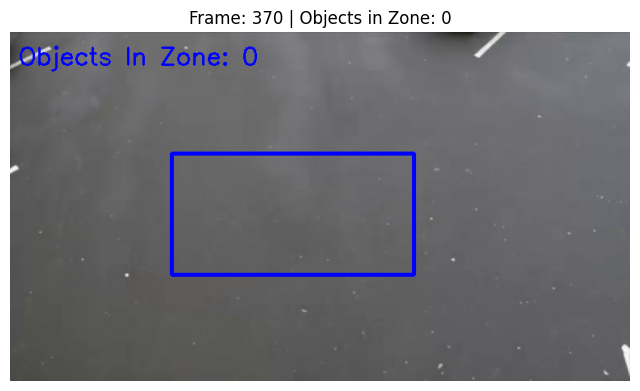

Video processing complete. Processed 377 frames.


In [17]:
# --- ENTER YOUR CODE HERE ---
from IPython.display import clear_output, display
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# We will use the video already downloaded in Part 1
video_path = 'highway.mp4'

# Task 1: Define your rectangular zone
# Coordinates: [x_min, y_min, x_max, y_max]
zone = [200, 150, 500, 300]

# Create your new agent function
def zone_counting_agent(video_path, zone_coords):
    print(f"Starting zone counting agent for {video_path}...")
    cap = cv2.VideoCapture(video_path)
    frame_count = 0

    if not cap.isOpened():
        print("Error: Could not open video file.")
        return

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # Track objects in the frame (Ensure persist=True for tracking)
        results = model.track(frame, persist=True, verbose=False)

        # Get the annotated frame
        annotated_frame = results[0].plot()

        # Visualizing the Zone: Draw the rectangular zone on the frame (Blue color)
        cv2.rectangle(annotated_frame, (zone_coords[0], zone_coords[1]), (zone_coords[2], zone_coords[3]), (255, 0, 0), 3)

        objects_in_zone_count = 0

        # Task 2: Modify the agent to count how many objects are inside the zone in each frame.
        if results[0].boxes.xyxy is not None:
            # Get bounding boxes as numpy array
            boxes = results[0].boxes.xyxy.cpu().numpy()
            for box in boxes:
                # Calculate the center point of the bounding box
                center_x = int((box[0] + box[2]) / 2)
                center_y = int((box[1] + box[3]) / 2)

                # Check if the center point is strictly inside the rectangular zone
                if (zone_coords[0] < center_x < zone_coords[2]) and \
                   (zone_coords[1] < center_y < zone_coords[3]):
                    objects_in_zone_count += 1

                    # Draw a red circle at the center of the object to show it's counted
                    cv2.circle(annotated_frame, (center_x, center_y), 5, (0, 0, 255), -1)

        # Task 3: Display the count on the frame
        cv2.putText(annotated_frame, f'Objects In Zone: {objects_in_zone_count}', (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

        # Display the frame smoothly
        if frame_count % 10 == 0:
            img = Image.fromarray(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
            clear_output(wait=True)
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.title(f'Frame: {frame_count} | Objects in Zone: {objects_in_zone_count}')
            plt.axis('off')
            plt.show()

    cap.release()
    print(f"Video processing complete. Processed {frame_count} frames.")

# Run your new agent
zone_counting_agent(video_path, zone)


## Reflective Questions

Please answer the following questions in a new Markdown cell below.

1.  What is the key difference between `model.predict()` and `model.track()` in the YOLO library?

- `model.predict()` performs object *detection* on individual, independent frames. It identifies what objects are in the frame and where they are, but assigns no persistent identity across a video.
- `model.track()` performs object *tracking*. It not only detects objects but also assigns a unique ID to each one, linking them from frame to frame so you can follow their trajectory over time.

2.  In our coded demonstration, we only counted an object once when it crossed the line. How did we achieve this? Why is it important?

- We achieved this by using a Python `set` called `crossed_objects` to store the unique `track_id` of each object that crossed the line. The code explicitly checks `if track_id not in crossed_objects` before adding it. This is important because without it, the same object would be counted multiple times (once for every frame it appears past the line), leading to highly inaccurate analytics.

3.  Describe a real-world application for zone-based analytics. What kind of zone would you define, and what would you measure?

- A common real-world application is retail store analytics. You could define a rectangular zone around a specific promotional display or aisle. You would measure the 'dwell time' (how long a person stays within that zone) or the total number of unique customers who enter the zone to gauge customer interest and the effectiveness of the promotion.

4.  What are some of the challenges in object tracking? (e.g., what happens if an object is hidden for a few frames?)

- A major challenge is occlusion, reading in to it, it is where an object is temporarily hidden behind another object or structure. If an object is hidden for a few frames, the tracker might lose it and assign it a brand new ID when it reappears (known as an "identity switch"). Other challenges include changes in lighting, variations in object scale (moving closer or further from the camera), motion blur from fast-moving objects, and cluttered scenes where many similar objects cross paths.

## Submission Instructions

1.  Complete the **Student Challenge** section with your modified agent.
2.  Answer the **Reflective Questions** in a new Markdown cell.
3.  Save your completed notebook (`.ipynb` file) and submit it.